In [8]:
# ============================================================
# ============================================================
# OLD vs NEW BANGLA PLATE MODEL — MOTION BLUR EVALUATION
#
# PURPOSE
# -------
# Compare your ORIGINAL YOLO model and your NEW
# motion-fine-tuned YOLO model on the SAME held-out test set.
#
# Tests:
#   1. Clean images
#   2. 5 px motion blur
#   3. 10 px motion blur
#   4. 15 px motion blur
#   5. 20 px motion blur
#
# Metrics:
#   - Exact token sequence accuracy
#   - Mean token accuracy
#   - Mean edit distance
#
# NO TRAINING IS DONE IN THIS FILE.
#

# ============================================================
import subprocess
import sys

def pip(*packages):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *packages],
        check=True
    )

pip("ultralytics==8.3.*")

print("Installation complete.")
from pathlib import Path
import zipfile
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Installation complete.


In [9]:


print("Searching for extracted best.pt contents...")

for p in Path("/kaggle/input").rglob("data.pkl"):
    print(p)

Searching for extracted best.pt contents...
/kaggle/input/datasets/tanvirmahtabtaneem/best-zip/best/data.pkl


In [10]:


data_files = list(
    Path("/kaggle/input").rglob("data.pkl")
)

best_dirs = []

for p in data_files:
    if p.parent.name == "best":
        best_dirs.append(p.parent)

if len(best_dirs) == 0:
    raise FileNotFoundError(
        "Could not find the extracted best model."
    )

if len(best_dirs) > 1:
    print("Multiple model folders found:")
    for p in best_dirs:
        print(p)

best_dir = best_dirs[0]

print("Using model folder:")
print(best_dir)

NEW_MODEL_PATH = Path(
    "/kaggle/working/best.pt"
)

with zipfile.ZipFile(
    NEW_MODEL_PATH,
    "w",
    compression=zipfile.ZIP_STORED
) as z:

    for file_path in best_dir.rglob("*"):

        if file_path.is_file():

            relative = file_path.relative_to(
                best_dir
            )

            archive_name = (
                Path("best") / relative
            )

            z.write(
                file_path,
                archive_name.as_posix()
            )

print("\nCreated:")
print(NEW_MODEL_PATH)

print(
    "Size:",
    NEW_MODEL_PATH.stat().st_size,
    "bytes"
)

Using model folder:
/kaggle/input/datasets/tanvirmahtabtaneem/best-zip/best

Created:
/kaggle/working/best.pt
Size: 40696293 bytes


In [11]:

model = YOLO(
    "/kaggle/working/best.pt"
)

print("===================================")
print("NEW FINE-TUNED MODEL LOADED")
print("===================================")

print(model.names)

NEW FINE-TUNED MODEL LOADED
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'Metro', 11: 'A', 12: 'Bha', 13: 'Cha', 14: 'Chha', 15: 'Da', 16: 'DA', 17: 'E', 18: 'Ga', 19: 'Gha', 20: 'Ha', 21: 'Ja', 22: 'Jha', 23: 'Ka', 24: 'Kha', 25: 'La', 26: 'Ma', 27: 'Na', 28: 'Pa', 29: 'Sa', 30: 'Sha', 31: 'Ta', 32: 'THA', 33: 'Tha', 34: 'U', 35: 'Bagerhat', 36: 'Bagura', 37: 'Bandarban', 38: 'Barguna', 39: 'Barisal', 40: 'Bhola', 41: 'Brahmanbaria', 42: 'Chandpur', 43: 'Chapainawabganj', 44: 'Chatto', 45: 'Chattogram', 46: 'Chuadanga', 47: "Cox's Bazar", 48: 'Cumilla', 49: 'Dhaka', 50: 'Dinajpur', 51: 'Faridpur', 52: 'Feni', 53: 'Gaibandha', 54: 'Gazipur', 55: 'Gopalganj', 56: 'Habiganj', 57: 'Jamalpur', 58: 'Jessore', 59: 'Jhalokati', 60: 'Jhenaidah', 61: 'Joypurhat', 62: 'Khagrachari', 63: 'Khulna', 64: 'Kishoreganj', 65: 'Kurigram', 66: 'Kustia', 67: 'Lakshmipur', 68: 'Lalmonirhat', 69: 'Madaripur', 70: 'Magura', 71: 'Manikganj', 72: 'Meherpur', 73: 'Moulvib

In [12]:
# ============================================================
# 1. CONFIGURATION

In [13]:
# ============================================================

# Original model — already trained previously.
OLD_MODEL_PATH = Path(
    "/kaggle/input/notebooks/tanvirmahtabtaneem/ocr-model/bangla_lpdb_runs/bangla_lpdb_yolo11m_t4x2/weights/best.pt"
)

# New fine-tuned model.
#
# This script first tries to find this automatically anywhere
# under /kaggle/input. If it is not found, replace this path
# with the saved-version path of your new best.pt.
NEW_MODEL_PATH = Path(
    "/kaggle/working/best.pt"
)

# Original public dataset.
DATASET_ROOT = Path(
    "/kaggle/input/datasets/tanvirmahtabtaneem/ocr-dataset/Bangla LPDB - A/Bangla_License_Plate"
)

CLASS_FILE = DATASET_ROOT / "classes.txt"

OUTPUT_ROOT = Path(
    "/kaggle/working/old_vs_new_motion_test"
)

RESULT_CSV = (
    OUTPUT_ROOT
    / "old_vs_new_motion_results.csv"
)

SUMMARY_CSV = (
    OUTPUT_ROOT
    / "old_vs_new_motion_summary.csv"
)

PLOT_FILE = (
    OUTPUT_ROOT
    / "old_vs_new_motion_accuracy.png"
)

CONF_THRESHOLD = 0.25

IMG_SIZE = 960

DEVICE = 0

SEED = 42

# These must remain the same as the original split.
TEST_RATIO = 0.10
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

# Blur levels used for evaluation.
BLUR_LEVELS = [
    0,
    5,
    10,
    15,
    20
]

# Number of test images to use.
# Set to None to evaluate all 268 test images.
MAX_TEST_IMAGES = None



In [14]:
# ============================================================
# 2. RANDOM SEED

In [15]:
# ============================================================

random.seed(SEED)
np.random.seed(SEED)



In [16]:
# ============================================================
# 3. OUTPUT FOLDER

In [17]:
# ============================================================

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)



In [18]:
# ============================================================
# 4. FIND NEW MODEL AUTOMATICALLY IF NEEDED

In [19]:
# ============================================================

def find_new_model():

    if NEW_MODEL_PATH.exists():
        return NEW_MODEL_PATH

    print(
        "Configured NEW_MODEL_PATH was not found."
    )

    print(
        "\nSearching /kaggle/input for "
        "bangla_lpdb_yolo11m_motion_finetune/weights/best.pt ..."
    )

    matches = list(
        Path("/kaggle/input").rglob(
            "bangla_lpdb_yolo11m_motion_finetune/weights/best.pt"
        )
    )

    if len(matches) == 1:
        print(
            "Found new model:",
            matches[0]
        )
        return matches[0]

    if len(matches) > 1:
        print(
            "\nMultiple new models found:"
        )

        for p in matches:
            print(p)

        raise RuntimeError(
            "Set NEW_MODEL_PATH manually because "
            "multiple fine-tuned models were found."
        )

    raise FileNotFoundError(
        "\nNew fine-tuned best.pt was not found.\n"
        "Change NEW_MODEL_PATH to the path of your "
        "saved fine-tuned best.pt."
    )


NEW_MODEL_PATH = find_new_model()



In [20]:
# ============================================================
# 5. CHECK FILES

In [21]:
# ============================================================

if not OLD_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Original best.pt not found:\n{OLD_MODEL_PATH}"
    )

if not NEW_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"New fine-tuned best.pt not found:\n{NEW_MODEL_PATH}"
    )

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_ROOT}"
    )

if not CLASS_FILE.exists():
    raise FileNotFoundError(
        f"classes.txt not found:\n{CLASS_FILE}"
    )

print("=" * 70)
print("MODELS")
print("=" * 70)

print("OLD MODEL:")
print(OLD_MODEL_PATH)

print("\nNEW MODEL:")
print(NEW_MODEL_PATH)



MODELS
OLD MODEL:
/kaggle/input/notebooks/tanvirmahtabtaneem/ocr-model/bangla_lpdb_runs/bangla_lpdb_yolo11m_t4x2/weights/best.pt

NEW MODEL:
/kaggle/working/best.pt


In [22]:
# ============================================================
# 6. LOAD CLASSES

In [23]:
# ============================================================

class_names = [
    x.strip()
    for x in CLASS_FILE.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()
    if x.strip()
]

print(
    "\nNumber of classes:",
    len(class_names)
)

if len(class_names) != 102:
    raise RuntimeError(
        f"Expected 102 classes, found {len(class_names)}."
    )




Number of classes: 102


In [24]:
# ============================================================
# 7. REPRODUCE THE SAME 80/10/10 TEST SPLIT

In [25]:
# ============================================================
#
# This reproduces the same split used during your training
# notebook because:
#   - same dataset
#   - same seed
#   - same ratios
#   - same shuffle method
#
# Therefore the evaluation uses the original held-out test set.

In [26]:
# ============================================================

pairs = []

images = sorted([
    p
    for p in DATASET_ROOT.iterdir()
    if p.suffix.lower()
    in [".jpg", ".jpeg", ".png"]
])

for image_path in images:

    label_path = image_path.with_suffix(".txt")

    if label_path.exists():
        pairs.append(
            (image_path, label_path)
        )

if len(pairs) == 0:
    raise RuntimeError(
        "No image/label pairs found."
    )

random.seed(SEED)
random.shuffle(pairs)

total = len(pairs)

train_end = int(
    total * TRAIN_RATIO
)

val_end = (
    train_end
    + int(total * VAL_RATIO)
)

train_pairs = pairs[:train_end]
val_pairs = pairs[train_end:val_end]
test_pairs = pairs[val_end:]

if MAX_TEST_IMAGES is not None:
    test_pairs = test_pairs[
        :MAX_TEST_IMAGES
    ]

print("\nDataset split:")
print(
    "Train:",
    len(train_pairs)
)
print(
    "Val:",
    len(val_pairs)
)
print(
    "Test:",
    len(test_pairs)
)




Dataset split:
Train: 2134
Val: 266
Test: 268


In [27]:
# ============================================================
# 8. LOAD MODELS

In [28]:
# ============================================================

print("\nLoading models...")

old_model = YOLO(
    str(OLD_MODEL_PATH)
)

new_model = YOLO(
    str(NEW_MODEL_PATH)
)

print("Both models loaded.")




Loading models...
Both models loaded.


In [29]:
# ============================================================
# 9. BLUR FUNCTION

In [30]:
# ============================================================

def apply_motion_blur(
    image,
    kernel_size
):

    if kernel_size == 0:
        return image.copy()

    kernel = np.zeros(
        (
            kernel_size,
            kernel_size
        ),
        dtype=np.float32
    )

    center = (
        kernel_size // 2
    )

    kernel[
        center,
        :
    ] = 1.0 / kernel_size

    return cv2.filter2D(
        image,
        -1,
        kernel
    )



In [31]:
# ============================================================
# 10. GROUND-TRUTH TOKEN ORDER

In [32]:
# ============================================================

def read_ground_truth(
    label_path
):

    tokens = []

    lines = label_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).splitlines()

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            continue

        try:

            class_id = int(
                float(parts[0])
            )

            cx = float(parts[1])
            cy = float(parts[2])
            w = float(parts[3])
            h = float(parts[4])

        except ValueError:
            continue

        if not (
            0 <= class_id < len(class_names)
        ):
            continue

        tokens.append({
            "class_id": class_id,
            "name": class_names[class_id],
            "cx": cx,
            "cy": cy,
            "width": w,
            "height": h
        })

    if not tokens:
        return []

    # Top to bottom.
    tokens.sort(
        key=lambda x: x["cy"]
    )

    # Group rows.
    rows = []

    for token in tokens:

        placed = False

        for row in rows:

            row_y = np.mean([
                x["cy"]
                for x in row
            ])

            if abs(
                token["cy"] - row_y
            ) <= 0.08:

                row.append(token)
                placed = True
                break

        if not placed:
            rows.append([
                token
            ])

    rows.sort(
        key=lambda row:
        np.mean([
            x["cy"]
            for x in row
        ])
    )

    for row in rows:

        row.sort(
            key=lambda x: x["cx"]
        )

    ordered = []

    for row in rows:
        ordered.extend(row)

    return [
        x["name"]
        for x in ordered
    ]



In [33]:
# ============================================================
# 11. PREDICT TOKEN ORDER

In [34]:
# ============================================================

def predict_tokens(
    model,
    image
):

    result = model.predict(
        source=image,
        imgsz=IMG_SIZE,
        conf=CONF_THRESHOLD,
        device=DEVICE,
        verbose=False
    )[0]

    if result.boxes is None:
        return []

    detections = []

    for i in range(
        len(result.boxes)
    ):

        confidence = float(
            result.boxes.conf[i].item()
        )

        if confidence < CONF_THRESHOLD:
            continue

        class_id = int(
            result.boxes.cls[i].item()
        )

        if not (
            0 <= class_id < len(class_names)
        ):
            continue

        x1, y1, x2, y2 = (
            result.boxes.xyxy[i]
            .cpu()
            .numpy()
            .tolist()
        )

        cx = (
            x1 + x2
        ) / 2.0

        cy = (
            y1 + y2
        ) / 2.0

        width = (
            x2 - x1
        )

        height = (
            y2 - y1
        )

        detections.append({
            "class_id": class_id,
            "name": class_names[class_id],
            "confidence": confidence,
            "cx": cx,
            "cy": cy,
            "width": width,
            "height": height
        })

    if not detections:
        return []

    # Top to bottom.
    detections.sort(
        key=lambda x: x["cy"]
    )

    rows = []

    for item in detections:

        placed = False

        for row in rows:

            row_y = np.mean([
                x["cy"]
                for x in row
            ])

            row_height = np.mean([
                x["height"]
                for x in row
            ])

            tolerance = (
                0.55 * row_height
            )

            if abs(
                item["cy"] - row_y
            ) <= tolerance:

                row.append(item)
                placed = True
                break

        if not placed:
            rows.append([
                item
            ])

    rows.sort(
        key=lambda row:
        np.mean([
            x["cy"]
            for x in row
        ])
    )

    for row in rows:

        row.sort(
            key=lambda x: x["cx"]
        )

    ordered = []

    for row in rows:
        ordered.extend(row)

    return [
        x["name"]
        for x in ordered
    ]



In [35]:
# ============================================================
# 12. LEVENSHTEIN DISTANCE

In [36]:
# ============================================================

def levenshtein(
    a,
    b
):

    n = len(a)
    m = len(b)

    dp = [
        [0] * (m + 1)
        for _ in range(n + 1)
    ]

    for i in range(
        n + 1
    ):
        dp[i][0] = i

    for j in range(
        m + 1
    ):
        dp[0][j] = j

    for i in range(
        1,
        n + 1
    ):

        for j in range(
            1,
            m + 1
        ):

            cost = (
                0
                if a[i - 1] == b[j - 1]
                else 1
            )

            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]



In [37]:
# ============================================================
# 13. EVALUATE ONE MODEL AT ONE BLUR LEVEL

In [38]:
# ============================================================

def evaluate_model(
    model,
    model_name,
    blur_level
):

    rows = []

    for index, (
        image_path,
        label_path
    ) in enumerate(test_pairs):

        image = cv2.imread(
            str(image_path)
        )

        if image is None:
            continue

        blurred = apply_motion_blur(
            image,
            blur_level
        )

        ground_truth = (
            read_ground_truth(
                label_path
            )
        )

        prediction = (
            predict_tokens(
                model,
                blurred
            )
        )

        exact = (
            prediction
            == ground_truth
        )

        edit_distance = levenshtein(
            ground_truth,
            prediction
        )

        denominator = max(
            len(ground_truth),
            1
        )

        token_accuracy = max(
            0.0,
            1.0
            - (
                edit_distance
                / denominator
            )
        )

        rows.append({
            "model": model_name,
            "blur": blur_level,
            "image": image_path.name,
            "ground_truth": " | ".join(
                ground_truth
            ),
            "prediction": " | ".join(
                prediction
            ),
            "exact_match": exact,
            "token_accuracy": token_accuracy,
            "edit_distance": edit_distance,
            "gt_count": len(
                ground_truth
            ),
            "pred_count": len(
                prediction
            )
        })

        if (
            index + 1
        ) % 25 == 0:

            print(
                f"{model_name} | "
                f"blur={blur_level} | "
                f"{index + 1}/{len(test_pairs)}"
            )

    return rows



In [39]:
# ============================================================
# 14. RUN COMPARISON

In [40]:
# ============================================================

print("\n" + "=" * 70)
print("STARTING OLD vs NEW COMPARISON")
print("=" * 70)

all_results = []

for blur_level in BLUR_LEVELS:

    print(
        "\n" + "-" * 70
    )

    print(
        "BLUR LEVEL:",
        blur_level
    )

    print(
        "-" * 70
    )

    old_results = evaluate_model(
        old_model,
        "OLD",
        blur_level
    )

    new_results = evaluate_model(
        new_model,
        "NEW",
        blur_level
    )

    all_results.extend(
        old_results
    )

    all_results.extend(
        new_results
    )




STARTING OLD vs NEW COMPARISON

----------------------------------------------------------------------
BLUR LEVEL: 0
----------------------------------------------------------------------
OLD | blur=0 | 25/268
OLD | blur=0 | 50/268
OLD | blur=0 | 75/268
OLD | blur=0 | 100/268
OLD | blur=0 | 125/268
OLD | blur=0 | 150/268
OLD | blur=0 | 175/268
OLD | blur=0 | 200/268
OLD | blur=0 | 225/268
OLD | blur=0 | 250/268
NEW | blur=0 | 25/268
NEW | blur=0 | 50/268
NEW | blur=0 | 75/268
NEW | blur=0 | 100/268
NEW | blur=0 | 125/268
NEW | blur=0 | 150/268
NEW | blur=0 | 175/268
NEW | blur=0 | 200/268
NEW | blur=0 | 225/268
NEW | blur=0 | 250/268

----------------------------------------------------------------------
BLUR LEVEL: 5
----------------------------------------------------------------------
OLD | blur=5 | 25/268
OLD | blur=5 | 50/268
OLD | blur=5 | 75/268
OLD | blur=5 | 100/268
OLD | blur=5 | 125/268
OLD | blur=5 | 150/268
OLD | blur=5 | 175/268
OLD | blur=5 | 200/268
OLD | blur=5 | 225/

In [41]:
# ============================================================
# 15. SAVE ALL RESULTS

In [42]:
# ============================================================

results_df = pd.DataFrame(
    all_results
)

results_df.to_csv(
    RESULT_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nSaved detailed results:"
)

print(
    RESULT_CSV
)




Saved detailed results:
/kaggle/working/old_vs_new_motion_test/old_vs_new_motion_results.csv


In [43]:
# ============================================================
# 16. SUMMARY TABLE

In [44]:
# ============================================================

summary = (
    results_df
    .groupby(
        ["model", "blur"],
        as_index=False
    )
    .agg(
        exact_accuracy=(
            "exact_match",
            "mean"
        ),
        mean_token_accuracy=(
            "token_accuracy",
            "mean"
        ),
        mean_edit_distance=(
            "edit_distance",
            "mean"
        ),
        images=(
            "image",
            "count"
        )
    )
)

summary[
    "exact_accuracy"
] *= 100

summary[
    "mean_token_accuracy"
] *= 100

summary.to_csv(
    SUMMARY_CSV,
    index=False
)

print(
    "\n" + "=" * 70
)

print(
    "SUMMARY"
)

print(
    "=" * 70
)

print(
    summary.to_string(
        index=False
    )
)




SUMMARY
model  blur  exact_accuracy  mean_token_accuracy  mean_edit_distance  images
  NEW     0       76.119403            92.893864            0.593284     268
  NEW     5       76.865672            93.033789            0.582090     268
  NEW    10       75.373134            92.292703            0.645522     268
  NEW    15       68.283582            90.258677            0.817164     268
  NEW    20       62.686567            87.549307            1.048507     268
  OLD     0       74.626866            92.374141            0.634328     268
  OLD     5       72.388060            92.337864            0.638060     268
  OLD    10       70.149254            91.099266            0.742537     268
  OLD    15       61.194030            88.341181            0.973881     268
  OLD    20       52.985075            83.926795            1.350746     268


In [45]:
# ============================================================
# 17. PIVOT TABLE — EXACT SEQUENCE ACCURACY

In [46]:
# ============================================================

pivot = summary.pivot(
    index="blur",
    columns="model",
    values="exact_accuracy"
)

print(
    "\nExact token-sequence accuracy (%):"
)

print(pivot)




Exact token-sequence accuracy (%):
model        NEW        OLD
blur                       
0      76.119403  74.626866
5      76.865672  72.388060
10     75.373134  70.149254
15     68.283582  61.194030
20     62.686567  52.985075


In [47]:
# ============================================================
# 18. PLOT OLD vs NEW

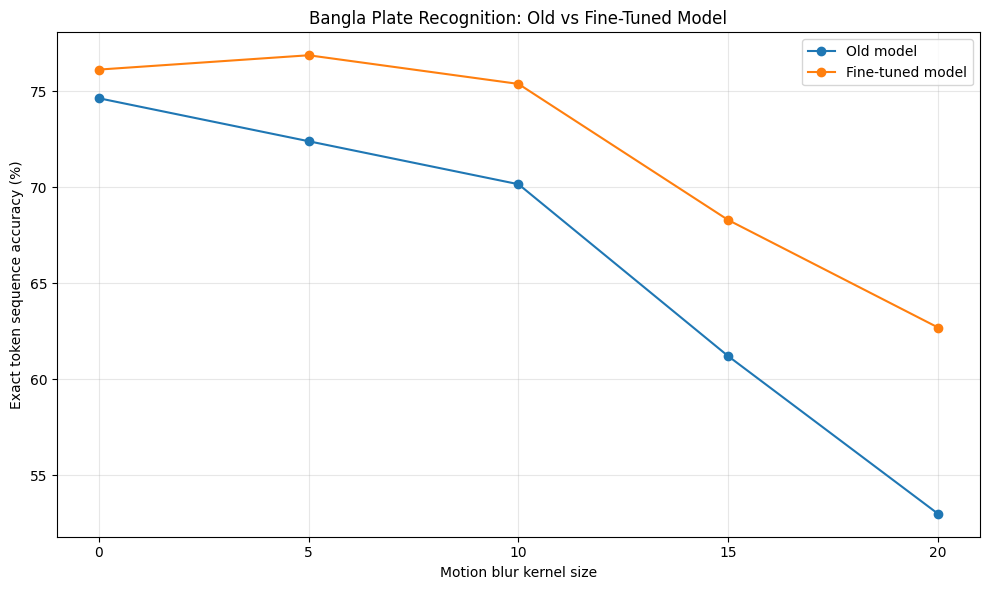

In [48]:
# ============================================================

plt.figure(
    figsize=(10, 6)
)

if "OLD" in pivot.columns:

    plt.plot(
        pivot.index,
        pivot["OLD"],
        marker="o",
        label="Old model"
    )

if "NEW" in pivot.columns:

    plt.plot(
        pivot.index,
        pivot["NEW"],
        marker="o",
        label="Fine-tuned model"
    )

plt.xlabel(
    "Motion blur kernel size"
)

plt.ylabel(
    "Exact token sequence accuracy (%)"
)

plt.title(
    "Bangla Plate Recognition: Old vs Fine-Tuned Model"
)

plt.xticks(
    BLUR_LEVELS
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    PLOT_FILE,
    dpi=200
)

plt.show()



In [49]:
# ============================================================
# 19. SHOW IMPROVEMENT

In [50]:
# ============================================================

if (
    "OLD" in pivot.columns
    and "NEW" in pivot.columns
):

    comparison = pd.DataFrame({
        "blur": pivot.index,
        "old_accuracy": pivot["OLD"].values,
        "new_accuracy": pivot["NEW"].values
    })

    comparison[
        "improvement"
    ] = (
        comparison["new_accuracy"]
        - comparison["old_accuracy"]
    )

    print(
        "\n" + "=" * 70
    )

    print(
        "IMPROVEMENT FROM FINE-TUNING"
    )

    print(
        "=" * 70
    )

    print(
        comparison.to_string(
            index=False
        )
    )

    best_row = comparison.loc[
        comparison["improvement"].idxmax()
    ]

    print(
        "\nLargest improvement:"
    )

    print(
        f'Blur {int(best_row["blur"])} px: '
        f'{best_row["improvement"]:+.2f} percentage points'
    )




IMPROVEMENT FROM FINE-TUNING
 blur  old_accuracy  new_accuracy  improvement
    0     74.626866     76.119403     1.492537
    5     72.388060     76.865672     4.477612
   10     70.149254     75.373134     5.223881
   15     61.194030     68.283582     7.089552
   20     52.985075     62.686567     9.701493

Largest improvement:
Blur 20 px: +9.70 percentage points


In [51]:
# ============================================================
# 20. SHOW FAILED EXAMPLES AT HEAVY BLUR

In [52]:
# ============================================================

heavy_failures = results_df[
    (
        results_df["blur"] == 20
    )
    &
    (
        results_df["exact_match"] == False
    )
]

print(
    "\n" + "=" * 70
)

print(
    "EXAMPLES OF FAILURES AT 20 PX BLUR"
)

print(
    "=" * 70
)

for _, row in heavy_failures.head(
    20
).iterrows():

    print(
        "\nMODEL:",
        row["model"]
    )

    print(
        "IMAGE:",
        row["image"]
    )

    print(
        "GT  :",
        row["ground_truth"]
    )

    print(
        "PRED:",
        row["prediction"]
    )

    print(
        "EDIT DISTANCE:",
        row["edit_distance"]
    )




EXAMPLES OF FAILURES AT 20 PX BLUR

MODEL: OLD
IMAGE: 1976.jpg
GT  : Jessore | E | 0 | 2 | 0 | 9 | 0 | 7
PRED: Jessore | 0 | 2 | 0 | 9 | 0 | 7
EDIT DISTANCE: 1

MODEL: OLD
IMAGE: 2395.jpg
GT  : Dhaka | Metro | Ka | 1 | 1 | 0 | 7 | 9 | 7
PRED: Dhaka | Metro | Ka | Ba | 1 | 1 | 0 | 7 | 9 | 7
EDIT DISTANCE: 1

MODEL: OLD
IMAGE: 1604.jpg
GT  : Thakurgaon | 1 | 2 | Ha | 0 | 1 | 3 | 6
PRED: 1 | 2 | Ha | 0 | 1 | 3 | 6
EDIT DISTANCE: 1

MODEL: OLD
IMAGE: 1786.jpg
GT  : Metro | Ga | Chatto | 3 | 3 | 2 | 1 | 3 | 9
PRED: Chatto | Metro | Ga | 1 | 3 | 9 | 3 | 3 | 2
EDIT DISTANCE: 6

MODEL: OLD
IMAGE: 371.jpg
GT  : Chatto | Metro | Da | 5 | 6 | 7 | 8 | 9 | 0
PRED: Chatto | Metro | Da | 5 | 6 | 7 | 8 | 9 | 0 | 0
EDIT DISTANCE: 1

MODEL: OLD
IMAGE: 1610.jpg
GT  : Jhenaidah | Ha | 1 | 5 | 2 | 9 | 4 | 6
PRED: Jhenaidah | Gha | 1 | 5 | 2 | 9 | 4 | 6
EDIT DISTANCE: 1

MODEL: OLD
IMAGE: 187.jpeg
GT  : Jamalpur | Tha | 1 | 1 | 0 | 6 | 6 | 2
PRED: Tha | 1 | 1 | 0 | 2
EDIT DISTANCE: 3

MODEL: OLD
IMAGE: 105

In [53]:
# ============================================================
# 21. FINAL OUTPUTS

In [54]:
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "EVALUATION COMPLETE"
)

print(
    "=" * 70
)

print(
    "Detailed CSV:",
    RESULT_CSV
)

print(
    "Summary CSV:",
    SUMMARY_CSV
)

print(
    "Plot:",
    PLOT_FILE
)



EVALUATION COMPLETE
Detailed CSV: /kaggle/working/old_vs_new_motion_test/old_vs_new_motion_results.csv
Summary CSV: /kaggle/working/old_vs_new_motion_test/old_vs_new_motion_summary.csv
Plot: /kaggle/working/old_vs_new_motion_test/old_vs_new_motion_accuracy.png


In [55]:
print("Loading new fine-tuned model...")

new_model_test = YOLO(
    "/kaggle/working/best.pt"
)

print()
print("======================================")
print("NEW MODEL LOADED SUCCESSFULLY")
print("======================================")
print("Number of classes:", len(new_model_test.names))
print("Classes:", new_model_test.names)

Loading new fine-tuned model...

NEW MODEL LOADED SUCCESSFULLY
Number of classes: 102
Classes: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'Metro', 11: 'A', 12: 'Bha', 13: 'Cha', 14: 'Chha', 15: 'Da', 16: 'DA', 17: 'E', 18: 'Ga', 19: 'Gha', 20: 'Ha', 21: 'Ja', 22: 'Jha', 23: 'Ka', 24: 'Kha', 25: 'La', 26: 'Ma', 27: 'Na', 28: 'Pa', 29: 'Sa', 30: 'Sha', 31: 'Ta', 32: 'THA', 33: 'Tha', 34: 'U', 35: 'Bagerhat', 36: 'Bagura', 37: 'Bandarban', 38: 'Barguna', 39: 'Barisal', 40: 'Bhola', 41: 'Brahmanbaria', 42: 'Chandpur', 43: 'Chapainawabganj', 44: 'Chatto', 45: 'Chattogram', 46: 'Chuadanga', 47: "Cox's Bazar", 48: 'Cumilla', 49: 'Dhaka', 50: 'Dinajpur', 51: 'Faridpur', 52: 'Feni', 53: 'Gaibandha', 54: 'Gazipur', 55: 'Gopalganj', 56: 'Habiganj', 57: 'Jamalpur', 58: 'Jessore', 59: 'Jhalokati', 60: 'Jhenaidah', 61: 'Joypurhat', 62: 'Khagrachari', 63: 'Khulna', 64: 'Kishoreganj', 65: 'Kurigram', 66: 'Kustia', 67: 'Lakshmipur', 68: 'Lalmonirhat', 69: 'Mada